# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick # for pretty graph labels
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import kagglehub
from scipy import stats
import os
import gc

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

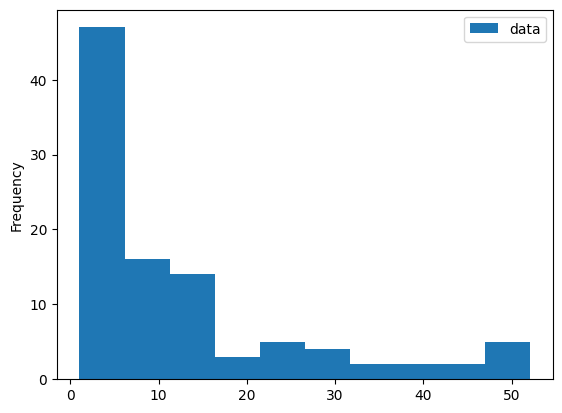

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

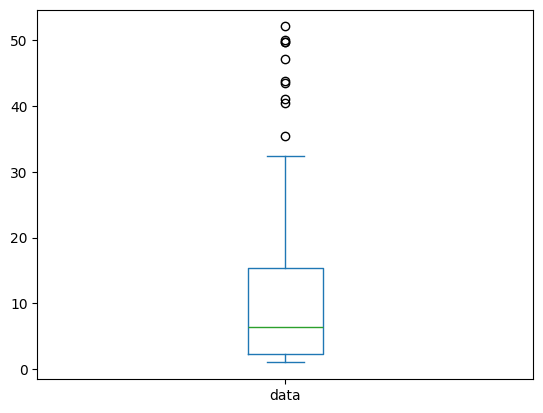

In [3]:
df.plot.box()

## Answer:
### The histogram and boxplot both show price distribution, but the histogram is better for visualizing how prices are spread out, especially for spotting clusters and skew toward higher-priced drugs. The boxplot, gives a cleaner summary of key statistics like median, quartiles, and outliers—making it easier to quickly see how expensive the top 25% of drugs are. For a clear picture of high-cost drugs in context, the boxplot is more concise, but combining both adds depth. 

### To improve the formatting, both the plots would benefit from clear titles, labeled axes (e.g., “Drug Price in USD”), and ticker formatting to show prices as currency. Adding measure indicators like mean or 75th percentile lines would give helpful context. Consistent color, like as highlighting outliers or specific price ranges, would make the plots more visually engaging. Overall, a cleaner layout and attention to styling would enhance clarity as well.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [4]:
# Load datasets
olist_dataset_link = "olistbr/brazilian-ecommerce"
vgrecs_dataset_link = "antonkozyriev/game-recommendations-on-steam"
vgsales_dataset_link = "ashaheedq/video-games-sales-2019"

olist_path = kagglehub.dataset_download(olist_dataset_link)
vgrec_path = kagglehub.dataset_download(vgrecs_dataset_link)
vgsales_path = kagglehub.dataset_download(vgsales_dataset_link)

In [5]:
# Load Video Game Sales data
vgsales_df_raw = pd.read_csv(os.path.join(vgsales_path, "vgsales-12-4-2019-short.csv"))
vgsales_df_cleaned = vgsales_df_raw.dropna(subset=["Year"])
vgsales_df_cleaned["ESRB_Rating"] = vgsales_df_cleaned["ESRB_Rating"].fillna("RP")
vgsales_df_cleaned["Developer"] = vgsales_df_cleaned["Developer"].fillna("Unknown")
sales_cols = ["Global_Sales", "NA_Sales", "PAL_Sales", "JP_Sales", "Other_Sales"]
vgsales_df_cleaned[sales_cols] = vgsales_df_cleaned[sales_cols].fillna(0)
vgsales_df_cleaned = vgsales_df_cleaned[vgsales_df_cleaned["Year"] <= 2025]
regional_sum = vgsales_df_cleaned[["NA_Sales", "PAL_Sales", "JP_Sales", "Other_Sales"]].sum(axis=1)
vgsales_df_cleaned = vgsales_df_cleaned[vgsales_df_cleaned["Global_Sales"] >= regional_sum]
vgsales_df_cleaned = vgsales_df_cleaned.drop(columns=["Total_Shipped"])

# Encode Video Game Sales
vgsales_df_cleaned_encoded = vgsales_df_cleaned.copy()
vgsales_df_cleaned_encoded = pd.get_dummies(vgsales_df_cleaned_encoded, columns=["Genre", "ESRB_Rating"], prefix=["Genre", "ESRB"])
top_platforms = vgsales_df_cleaned_encoded["Platform"].value_counts().nlargest(10).index
vgsales_df_cleaned_encoded["Platform"] = vgsales_df_cleaned_encoded["Platform"].where(vgsales_df_cleaned_encoded["Platform"].isin(top_platforms), other="Other")
vgsales_df_cleaned_encoded = pd.get_dummies(vgsales_df_cleaned_encoded, columns=["Platform"], prefix="Platform")
for col in ["Publisher", "Developer"]:
    freq_map = vgsales_df_cleaned_encoded[col].value_counts(normalize=True)
    vgsales_df_cleaned_encoded[col + "_freq"] = vgsales_df_cleaned_encoded[col].map(freq_map)
vgsales_df_cleaned_encoded = vgsales_df_cleaned_encoded.drop(columns=["Publisher", "Developer"])

/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_5891/2315962133.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vgsales_df_cleaned["ESRB_Rating"] = vgsales_df_cleaned["ESRB_Rating"].fillna("RP")
/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_5891/2315962133.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vgsales_df_cleaned["Developer"] = vgsales_df_cleaned["Developer"].fillna("Unknown")
/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_5891/2315962133.py:7: SettingWit

In [6]:
# Load Video Game Recommendations data
vgrecs_recs_df_raw = pd.read_csv(os.path.join(vgrec_path, "recommendations.csv"))
vgrecs_users_df_raw = pd.read_csv(os.path.join(vgrec_path, "users.csv"))
vgrecs_games_df_raw = pd.read_csv(os.path.join(vgrec_path, "games.csv"))

vgrecs_merged_df = vgrecs_recs_df_raw.merge(vgrecs_users_df_raw, on="user_id", how="left")
vgrecs_merged_df = vgrecs_merged_df.merge(vgrecs_games_df_raw, on="app_id", how="left")
vgrecs_merged_df["date_release"] = pd.to_datetime(vgrecs_merged_df["date_release"], errors="coerce")
print(f"Raw: {vgrecs_merged_df.shape}")
# cut data in quarter because it is too large for my kernel
vgrecs_merged_df = vgrecs_merged_df.sample(frac=0.10, random_state=42)
# remove anything with price over 175, it makes no sense to unneccesarily distort games
vgrecs_merged_df = vgrecs_merged_df[vgrecs_merged_df["price_final"] <= 175]

print(f"Cleaned: {vgrecs_merged_df.shape}")

# clean up the unused dataframes
del vgrecs_recs_df_raw
del vgrecs_users_df_raw
del vgrecs_games_df_raw
gc.collect()

# Encode Video Game Recommendations
# vgrecs_merged_df_encoded = vgrecs_merged_df.copy()
# rating_order = ['Overwhelmingly Negative', 'Very Negative', 'Mostly Negative', 'Negative', 'Mixed', 'Positive', 'Mostly Positive', 'Very Positive', 'Overwhelmingly Positive']
# rating_map = {label: idx for idx, label in enumerate(rating_order)}
# vgrecs_merged_df_encoded['rating_encoded'] = vgrecs_merged_df_encoded['rating'].map(rating_map)

Raw: (41154794, 22)
Cleaned: (4115463, 22)


6

In [7]:
# Load Olist datasets
olist_products_df_raw = pd.read_csv(os.path.join(olist_path, "olist_products_dataset.csv"))
olist_translation_df_raw = pd.read_csv(os.path.join(olist_path, "product_category_name_translation.csv"))
olist_reviews_df_raw = pd.read_csv(os.path.join(olist_path, "olist_order_reviews_dataset.csv"))
olist_orders_df_raw = pd.read_csv(os.path.join(olist_path, "olist_orders_dataset.csv"))
olist_customers_df_raw = pd.read_csv(os.path.join(olist_path, "olist_customers_dataset.csv"))
olist_items_df_raw = pd.read_csv(os.path.join(olist_path, "olist_order_items_dataset.csv"))

# Merge Olist data
olist_products_df = olist_products_df_raw.merge(olist_translation_df_raw, how="left", on="product_category_name")
olist_order_lines_df = olist_items_df_raw.merge(olist_products_df, how="left", on="product_id")
olist_order_lines_df = olist_order_lines_df.merge(olist_orders_df_raw[["order_id", "customer_id", "order_purchase_timestamp"]], how="left", on="order_id")
olist_order_lines_df = olist_order_lines_df.merge(olist_customers_df_raw[["customer_id", "customer_unique_id", "customer_state"]], how="left", on="customer_id")
olist_merged_df = olist_order_lines_df.merge(olist_reviews_df_raw[["order_id", "review_score", "review_creation_date", "review_answer_timestamp"]], how="left", on="order_id")

# Clean Olist
olist_cleaned_df = olist_merged_df.drop_duplicates()
olist_cleaned_df = olist_cleaned_df.dropna(subset=["product_category_name", "product_category_name_english", "review_score", "product_weight_g"])
olist_cleaned_df["review_creation_date"] = pd.to_datetime(olist_cleaned_df["review_creation_date"])
olist_cleaned_df["order_purchase_timestamp"] = pd.to_datetime(olist_cleaned_df["order_purchase_timestamp"])
olist_cleaned_df["days_to_review"] = olist_cleaned_df["review_creation_date"] - olist_cleaned_df["order_purchase_timestamp"]
olist_cleaned_df = olist_cleaned_df[olist_cleaned_df["days_to_review"] >= pd.Timedelta(0)]
olist_cleaned_df = olist_cleaned_df.rename(columns={
    "product_name_lenght": "product_name_length",
    "product_description_lenght": "product_description_length"
})
olist_cleaned_df = olist_cleaned_df.drop(columns=["product_category_name"])

# Encode Olist
olist_cleaned_encoded_df = olist_cleaned_df.drop(columns=[
    "order_id", "customer_id", "product_id", "seller_id", "customer_unique_id",
    "review_creation_date", "shipping_limit_date", "review_answer_timestamp"
])
olist_cleaned_encoded_df = pd.get_dummies(olist_cleaned_encoded_df, columns=["product_category_name_english", "customer_state"])
olist_cleaned_encoded_df["days_to_review"] = olist_cleaned_encoded_df["days_to_review"].dt.total_seconds() / 86400


# Video Game Sales Dataset


## Features (from kaggle)
| Column Name    | Description                                             |
|----------------|---------------------------------------------------------|
| Rank           | Ranking of overall sales                                |
| Name           | Name of the game                                        |
| Platform       | Platform of the game (i.e. PC, PS4, XOne, etc.)         |
| Genre          | Genre of the game                                       |
| ESRB Rating    | ESRB Rating of the game                                 |
| Publisher      | Publisher of the game                                   |
| Developer      | Developer of the game                                   |
| Critic Score   | Critic score of the game out of 10                      |
| User Score     | Users score the game out of 10                          |
| Total Shipped  | Total shipped copies of the game                        |
| Global_Sales   | Total worldwide sales (in millions)                     |
| NA_Sales       | Sales in North America (in millions)                    |
| PAL_Sales      | Sales in Europe (in millions)                           |
| JP_Sales       | Sales in Japan (in millions)                            |
| Other_Sales    | Sales in the rest of the world (in millions)            |
| Year           | Year of release of the game                             |


In [8]:
# Consolidate variables
# cleaned + not encoded
vgsales_cleaned_df = vgsales_df_cleaned.copy()
# get rid of the null values from before just for EDA
vgsales_cleaned_df = vgsales_cleaned_df.dropna(subset=["Critic_Score", "User_Score"])

# cleaned + encoded
vgsales_encoded_df = vgsales_df_cleaned_encoded.copy()



In [9]:
# Getting the unique columns
vgsales_cleaned_df.columns

Index(['Rank', 'Name', 'Genre', 'ESRB_Rating', 'Platform', 'Publisher',
       'Developer', 'Critic_Score', 'User_Score', 'Global_Sales', 'NA_Sales',
       'PAL_Sales', 'JP_Sales', 'Other_Sales', 'Year'],
      dtype='object')

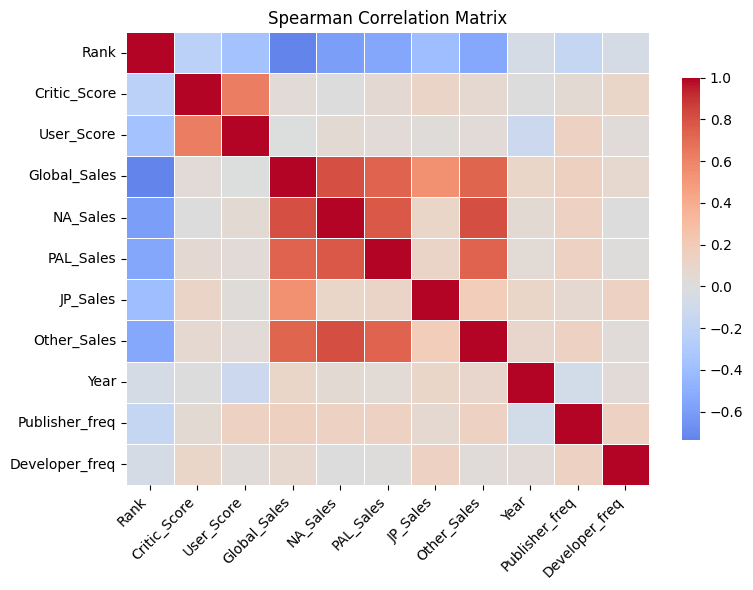

In [10]:
# Creating a correlation matrix heatmap

# drop non-numeric columns
numeric_df = vgsales_encoded_df.select_dtypes(include=[np.number])
# numeric_df.drop(["NA_Sales", "PAL_Sales", "JP_Sales", "Other_Sales"], axis=1, inplace=True)
# get Spearman correlation matrix
correlation_matrix = numeric_df.corr(method='spearman')

# make heatmap of the correlation
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()


### It seems that the regional sales metrics are all strongly correlated with the global sales, which makes sense because the global sales are a sum of the regional sales. Additionally, the rank is inversely correlated with the sales, which makes sense because the game's sales and popularity is an indicator of the rank (lower number, higher rank). However, there is little intercorrelation between any other columns.

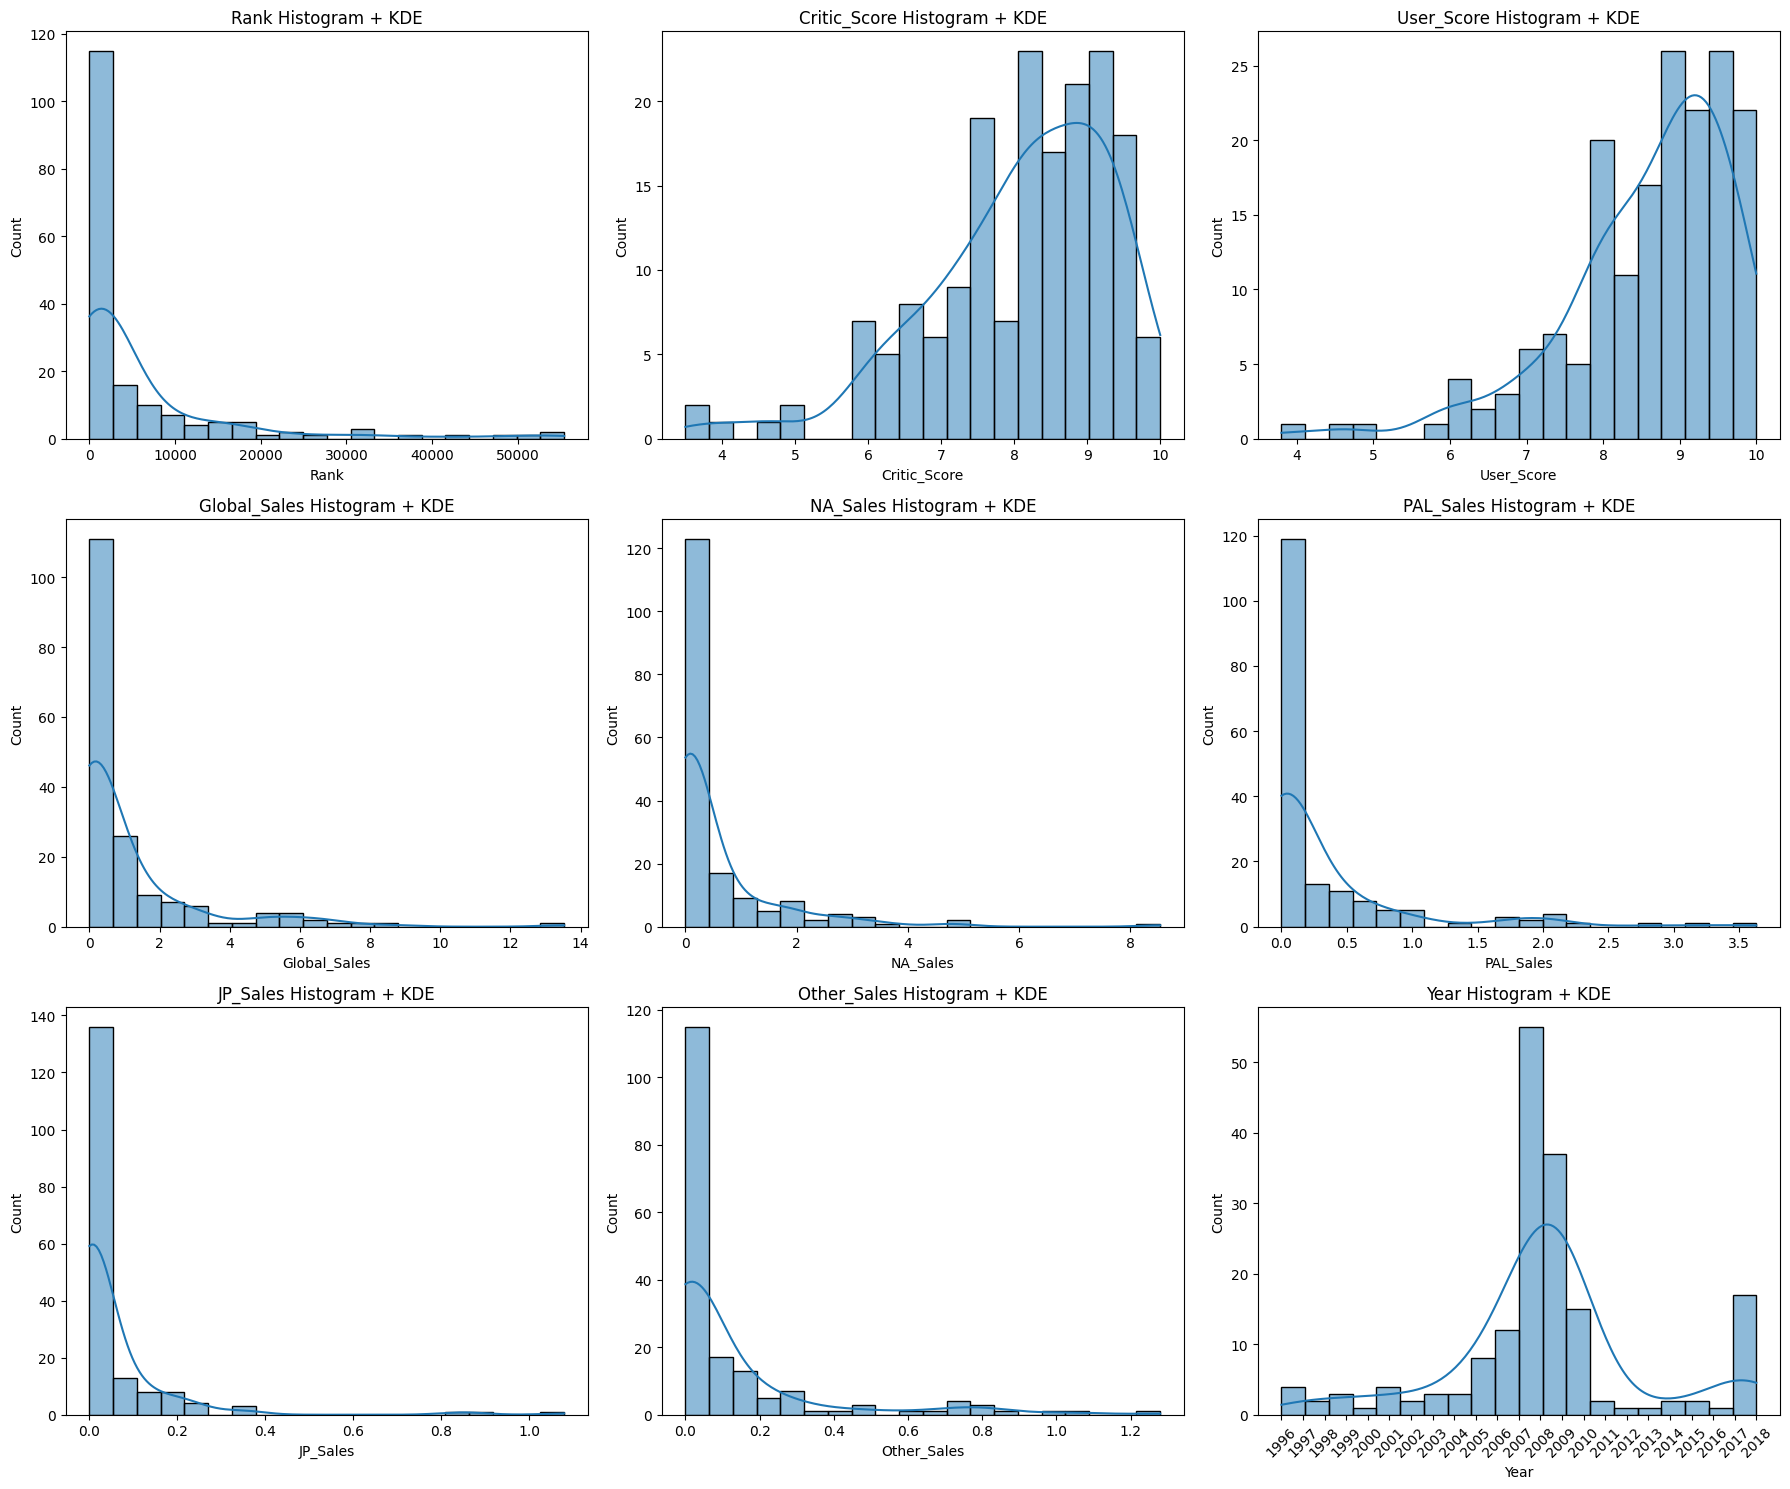

In [11]:
# Making a histogram subplot with kernel density estimations

# only numeric columns
numeric_cols = vgsales_cleaned_df.select_dtypes(include=np.number).columns

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# iterate throught the columns to make subplots
for i, col in enumerate(numeric_cols):
    sns.histplot(data=vgsales_cleaned_df, x=col, kde=True, ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(f"{col} Histogram + KDE")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

    # case for 'Year' to show 1 tick per year
    if col == "Year":
        years = sorted(vgsales_cleaned_df["Year"].dropna().unique())
        axes[i].set_xticks(years)
        axes[i].set_xticklabels([int(y) for y in years], rotation=45)

# lez go
plt.tight_layout()
plt.show()


### The critic and user scores are skewed to the right, meaning there are more "good" games than bad ones. A lot of the global sales numbers are zero because the figures are either null, or less than 1 million, since "1" represents 1 million sales in the dataset. It seems that the dataset captured a lot of games published in 2007.

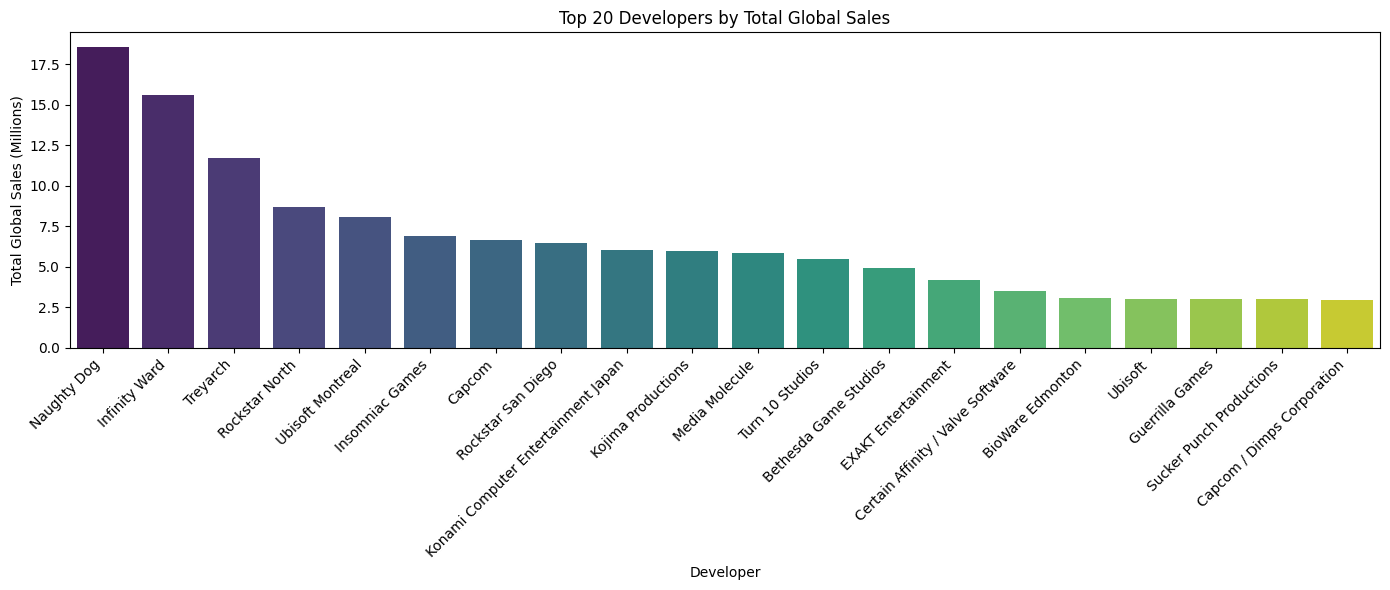

In [12]:
# Group by Developer, sum Global_Sales, sort by total sales
dev_sales = vgsales_cleaned_df.groupby("Developer")["Global_Sales"].sum().sort_values(ascending=False).head(20)

# Plot
plt.figure(figsize=(14, 6))
sns.barplot(x=dev_sales.index, y=dev_sales.values, palette="viridis", hue=dev_sales.index)

plt.title("Top 20 Developers by Total Global Sales")
plt.xlabel("Developer")
plt.ylabel("Total Global Sales (Millions)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Naughty Dog, Infinity Ward, and Treyarch are the 3 highest-selling developers according to total worldwide sales

/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_5891/2871540307.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_games["Label"], y=top_games["Global_Sales"], palette="mako")


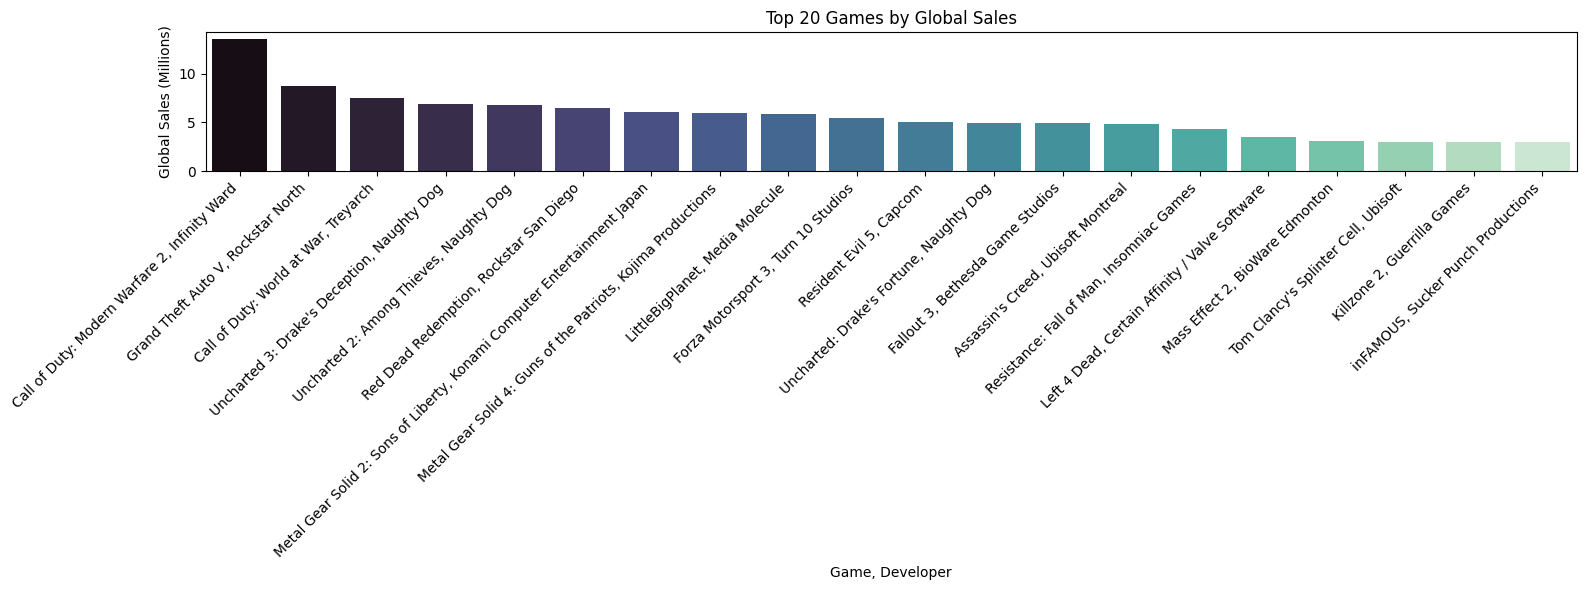

In [13]:
# Get top 20 games by Global_Sales
top_games = vgsales_cleaned_df.sort_values("Global_Sales", ascending=False).head(20)

# Combine Name and Developer for x-axis labels
top_games["Label"] = top_games["Name"] + ", " + top_games["Developer"]

# Plot
plt.figure(figsize=(16, 6))
sns.barplot(x=top_games["Label"], y=top_games["Global_Sales"], palette="mako")

plt.title("Top 20 Games by Global Sales")
plt.xlabel("Game, Developer")
plt.ylabel("Global Sales (Millions)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Call of Duty (CoD): Modern Warfare 2 is the highest selling video game, followed by GTA 5, CoD World at War, and Uncharted 3 and 2 - as the top 5 highest selling video games in this dataset

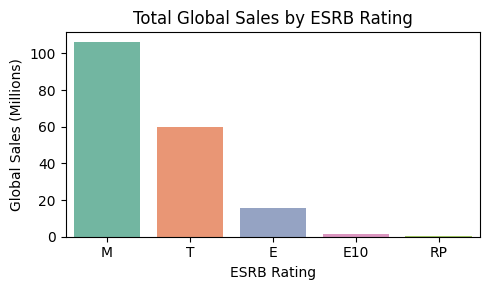

array(['E', 'M', 'T', 'E10', 'RP'], dtype=object)

In [14]:
# Group by ESRB Rating and sum Global Sales
esrb_sales = vgsales_cleaned_df.groupby("ESRB_Rating")["Global_Sales"].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(5, 3))
sns.barplot(x=esrb_sales.index, y=esrb_sales.values, palette="Set2", hue=esrb_sales.index)

plt.title("Total Global Sales by ESRB Rating")
plt.xlabel("ESRB Rating")
plt.ylabel("Global Sales (Millions)")
plt.tight_layout()
plt.show()

vgsales_cleaned_df["ESRB_Rating"].unique()


### The M (Mature) category on the age rating score ranks as having the most sales, followed by T (Teen)

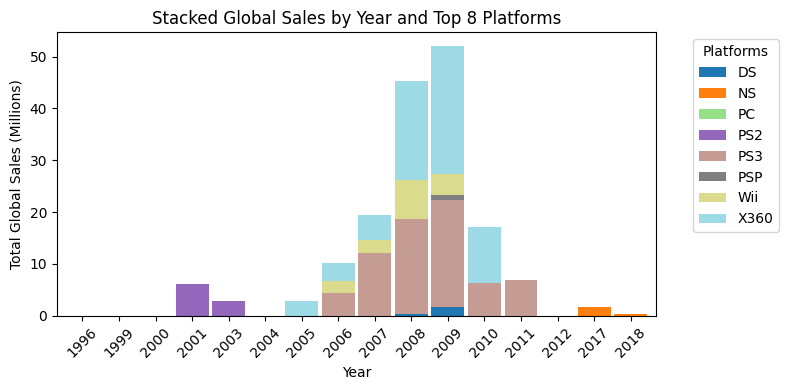

In [15]:
# Stacked bar chart of platforms and sales by year
# clean up year
df = vgsales_cleaned_df.copy()
df = df[df["Year"].between(1980, 2025)]
df["Year"] = df["Year"].astype(int)
# get the top 8 platformss
top_platforms = df["Platform"].value_counts().nlargest(8).index
df = df[df["Platform"].isin(top_platforms)]

# create pivot table where rows = Year, columns = platform, values = Global_Sales
pivot_df = df.pivot_table(index="Year", columns="Platform", values="Global_Sales", aggfunc="sum", fill_value=0)

# plot the thing
fig, ax = plt.subplots(figsize=(8, 4))
pivot_df.plot(kind="bar", stacked=True, colormap="tab20", ax=ax, width=0.9)
# fix the labels
ax.set_title("Stacked Global Sales by Year and Top 8 Platforms")
ax.set_xlabel("Year")
ax.set_ylabel("Total Global Sales (Millions)")
ax.legend(title="Platforms", bbox_to_anchor=(1.05, 1), loc='upper left')

# format x-axis
ax.set_xticks(range(len(pivot_df.index)))
ax.set_xticklabels(pivot_df.index.astype(int), rotation=45)

plt.tight_layout()
plt.show()


### Game sales peaked between 2007 and 2009, driven by X360, PS3, and Wii. After 2011, sales dropped sharply, suggesting missing or incomplete data. Xbox 360 led in volume, but the PS3 had consistent performance across years. Newer platforms like the Switch (NS) appear late and minimally, likely due to the recency of this dataset.

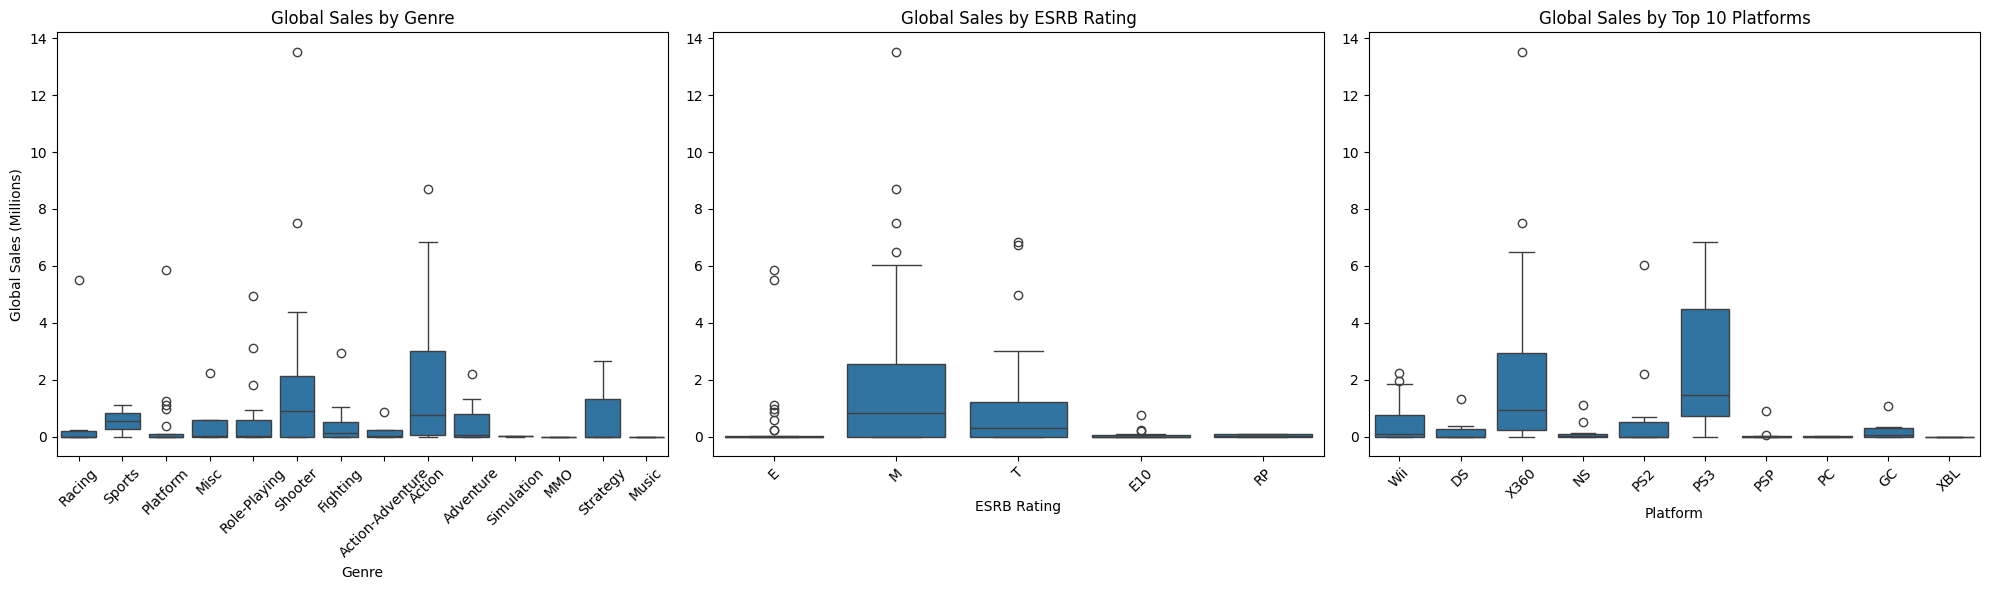

In [16]:
# Boxplots according to platforms, genre, and esrb rating

# top 10 platforms only
top_platforms = vgsales_cleaned_df["Platform"].value_counts().nlargest(10).index
platform_df = vgsales_cleaned_df[vgsales_cleaned_df["Platform"].isin(top_platforms)]
#subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Boxplot 1: Genre
sns.boxplot(data=vgsales_cleaned_df, x="Genre", y="Global_Sales", ax=axes[0], showfliers=True)
axes[0].set_title("Global Sales by Genre")
axes[0].set_xlabel("Genre")
axes[0].set_ylabel("Global Sales (Millions)")
axes[0].tick_params(axis='x', rotation=45)

# boxplot 2: ESRB Rating
sns.boxplot(data=vgsales_cleaned_df, x="ESRB_Rating", y="Global_Sales", ax=axes[1], showfliers=True)
axes[1].set_title("Global Sales by ESRB Rating")
axes[1].set_xlabel("ESRB Rating")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=45)

# boxplot 3: Platform (Top 10)
sns.boxplot(data=platform_df, x="Platform", y="Global_Sales", ax=axes[2], showfliers=True)
axes[2].set_title("Global Sales by Top 10 Platforms")
axes[2].set_xlabel("Platform")
axes[2].set_ylabel("")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Action and Shooter genres have the highest median sales and widest spread. They're top contenders for predicting success among videogames. Platform, MMO, Simulation, Strategy, Music genres show consistently low sales — likely weak predictors unless interaction effects matter. Action-Adventure has a wide IQR and many outliers, suggesting some games in this category break into higher sales territory.


### M-rated (Mature) games dominate in terms of both median and spread, and include some of the largest outliers - these are big sellers. E (Everyone) is surprisingly low in both median and variance, which might challenge the usual assumption that family-friendly = high sales. RP (Rating Pending) and E10+ contribute almost nothing — i'm considering excluding them or treating as noise during modeling.

### PS3 and X360 (PlayStation 3 and Xbox 360) have the highest medians, wide spreads, and many outliers. PS2 has a few high sellers, but lower median than expected for such a popular console — this might indicate market saturation or poor data coverage. the Wii shows high skew: lower median, but some huge outliers (very successful first-party games). PC, PSP, GCN, XBL platforms are low in both median and spread — these are weak standalone predictors for modelling.

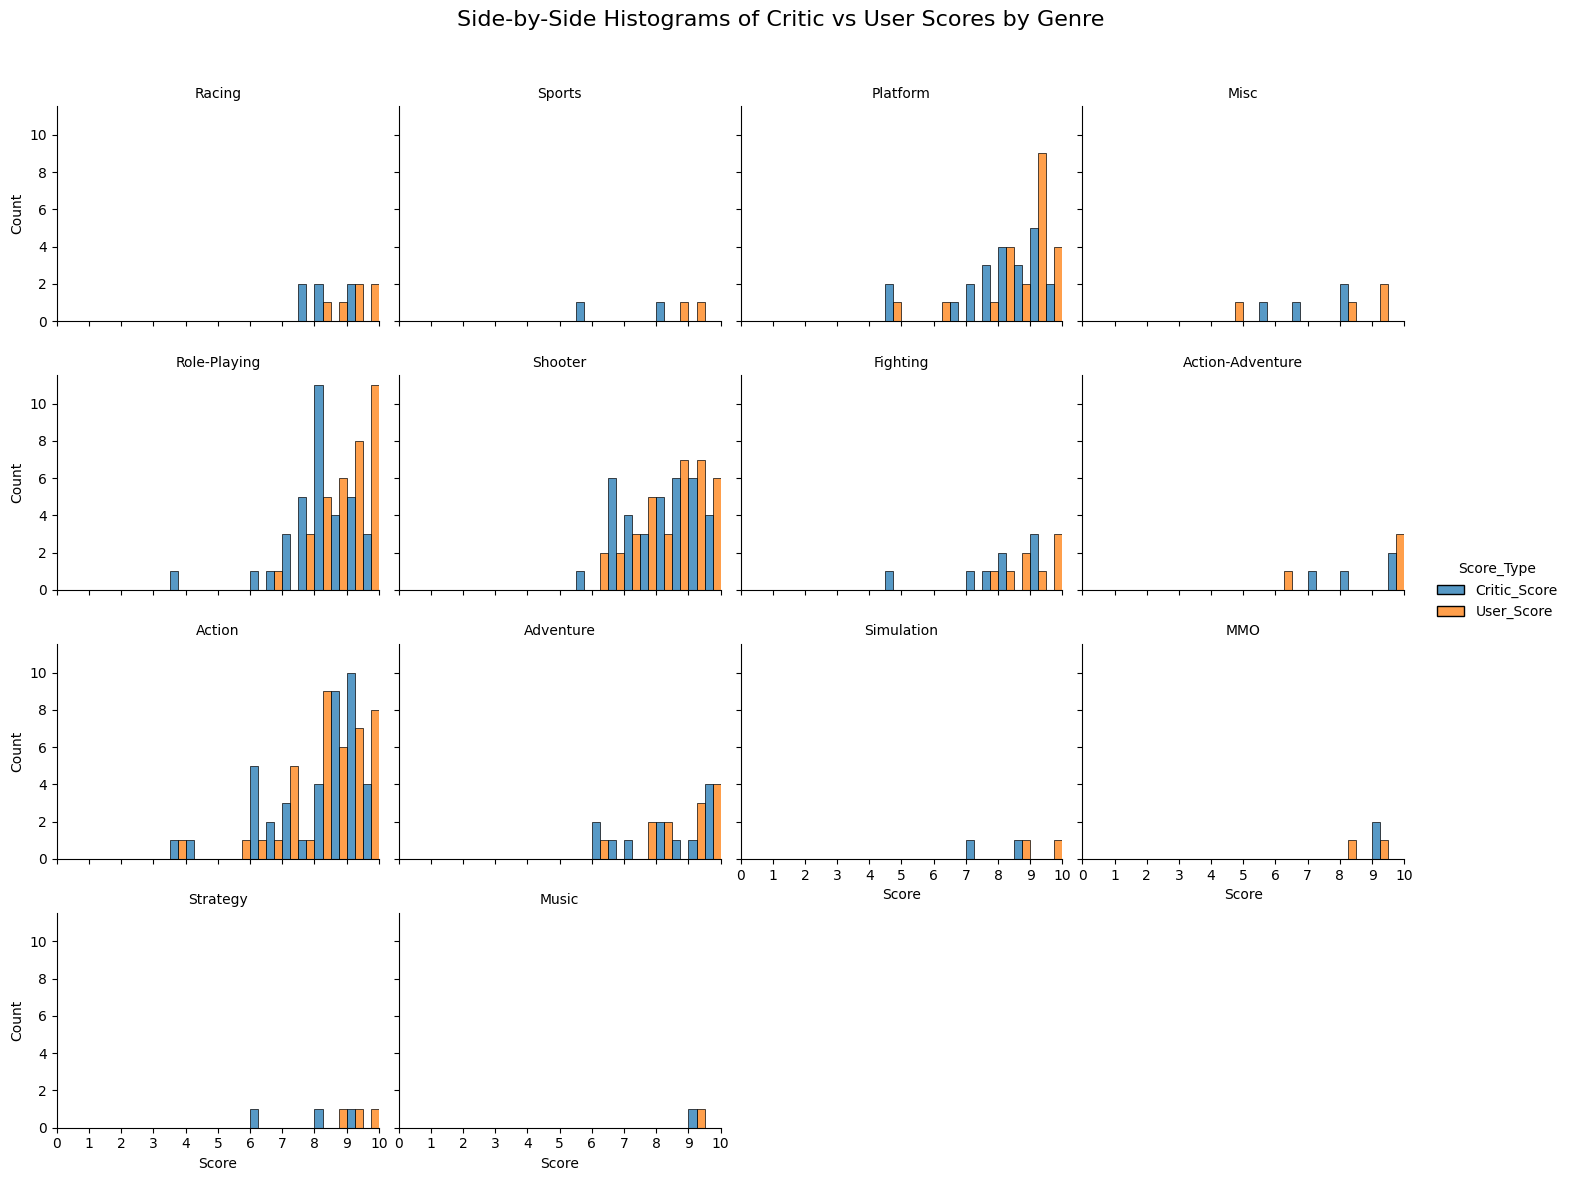

In [17]:

# Melt to long format
score_melted = vgsales_cleaned_df.melt(
    id_vars=["Genre"],
    value_vars=["Critic_Score", "User_Score"],
    var_name="Score_Type",
    value_name="Score"
)

# Drop missing values
score_melted = score_melted.dropna(subset=["Score"])

# Normalize Critic_Score if it's on a 0–100 scale
max_critic = score_melted.loc[score_melted["Score_Type"] == "Critic_Score", "Score"].max()
if max_critic > 10:
    score_melted.loc[score_melted["Score_Type"] == "Critic_Score", "Score"] /= 10

# Plot: side-by-side histograms
g = sns.displot(
    data=score_melted,
    x="Score",
    hue="Score_Type",
    col="Genre",
    col_wrap=4,
    kind="hist",
    bins=np.linspace(0, 10, 21),
    common_bins=True,
    common_norm=False,
    multiple="dodge",
    height=3,
    aspect=1.2,
    facet_kws={'sharex': True, 'sharey': True}
)

# Set x-ticks and clean titles
for ax in g.axes.flatten():
    ax.set_xticks(np.arange(0, 11, 1))
    ax.set_xlim(0, 10)
    ax.set_title(ax.get_title().replace("Genre = ", ""), fontsize=10)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Side-by-Side Histograms of Critic vs User Scores by Genre", fontsize=16)
plt.show()


### Most genres show critic and user scores clustering in the 7–9 range, indicating general agreement in perceived quality, though users tend to rate slightly higher in genres like Role-Playing and Action. Some genres like Platform, Adventure, and MMO show more polarized user scores, hinting at niche appeal or cult followings not reflected in critic consensus. Genres like Music, Strategy, and Simulation have too few data points for meaningful interpretation and may need to be excluded or grouped in modeling.

# Video game Sales Dataset Conclusion:

### This dataset looks usable overall, but it needs some cleanup — especially getting rid of junk categories like RP and E10+ that don’t add much. Most of the sales numbers are heavily right-skewed, meaning that a lot of games sold barely anything while a few sold huge amounts. There are definitely outliers, especially in the Action and Shooter genres, M-rated games, and platforms like PS3 and X360 are the most popular. Different groups tell different stories: some genres and consoles do great, others barely register. The lowest sales are basically zero, and the top games go  past 10 million copies. Changing the bin sizes in histograms really helps show where most games fall and where the rare bestsellers are hiding. Scores from critics and users lean positive, which is what you’d expect — more good games than bad ones, at least in the ratings. All in all, the data isn’t normal, but it tells a useful story if you clean it up first.

# Video Game Recommendations Dataset

## Features
| Column Name     | Data Type  | Description                                                   |
|----------------|------------|---------------------------------------------------------------|
| app_id         | int64      | Unique game identifier on Steam                               |
| helpful        | int64      | How many users found the recommendation helpful               |
| funny          | int64      | How many users found the recommendation funny                 |
| date           | object     | Date of publishing                                            |
| is_recommended | bool       | Is the user recommending the product?                         |
| hours          | float64    | How many hours played by the reviewing user                   |
| user_id        | int64      | User's anonymized ID                                          |
| review_id      | int64      | Autogenerated ID for the review itself                        |
| products       | int64      | Number of games/add-ons purchased by the user                 |
| reviews        | int64      | Number of reviews published by the reviewing user             |
| title          | object     | Name of the game being reviewed                               |
| date_release   | object     | Game's date of release                                        |
| win            | bool       | Supports Windows OS                                           |
| mac            | bool       | Supports Mac OS                                               |
| linux          | bool       | Supports Linux OS                                             |
| rating         | object     | Product rating category                                       |
| positive_ratio | int64      | Ratio of positive feedbacks (%)                               |
| user_reviews   | int64      | Number of user reviews available on the Steam page            |
| price_final    | float64    | Price in US dollars ($) calculated after the discount         |
| price_original | float64    | Price in US dollars ($) before the discount                   |
| discount       | float64    | Discount percentage                                            |
| steam_deck     | bool       | Supports the Steam Deck                                       |


In [18]:
# consolidate variables
vgrecs_cleaned_df = vgrecs_merged_df
# vgrecs_encoded_df = vgrecs_merged_df_encoded.copy()

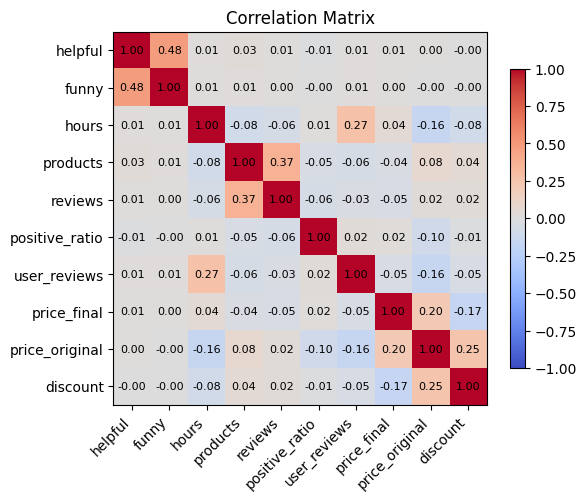

In [19]:

# Compute the correlation matrix
numeric_cols = vgrecs_cleaned_df.select_dtypes(include=np.number).drop(["app_id", "user_id", "review_id"], axis=1)
corr_matrix = numeric_cols.corr()

# Plot it using imshow
plt.figure(figsize=(6, 5))
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

# Add colorbar
plt.colorbar(im, shrink=0.8)

# Add rotated axis ticks
plt.xticks(ticks=np.arange(len(corr_matrix.columns)), 
           labels=corr_matrix.columns, 
           rotation=45, 
           ha="right")
plt.yticks(ticks=np.arange(len(corr_matrix.columns)), 
           labels=corr_matrix.columns)

# Annotate each cell with the correlation coefficient
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black", fontsize=8)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


### Helpful vs funny → 0.50 Reviews marked as funny are also often marked helpful. This suggests humor boosts perceived helpfulness. reviews vs products → 0.37 - Users who own more products also write more reviews — this confirms more active users tend to contribute more. reviews vs hours → 0.28, players who play more also write more reviews. So engagement is linked to review activity.

### discount, price_final, and price_original are very closely linked because they are derivatives of each other, these will be dropped due to multicollinearity for the final model.z

### The hours has low correlation with almost everything (max is ~0.27 with user_reviews). That means playtime isn’t strongly predictive of review helpfulness, funniness, or review count. positive_ratio also shows weak correlation with all features. This suggests that positivity rating is not tightly linked to any single numeric input here (it might be driven by more complex factors like review text or game genre).

/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_5891/1543773342.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  vgrecs_cleaned_df["rating"].fillna("Unknown", inplace=True)


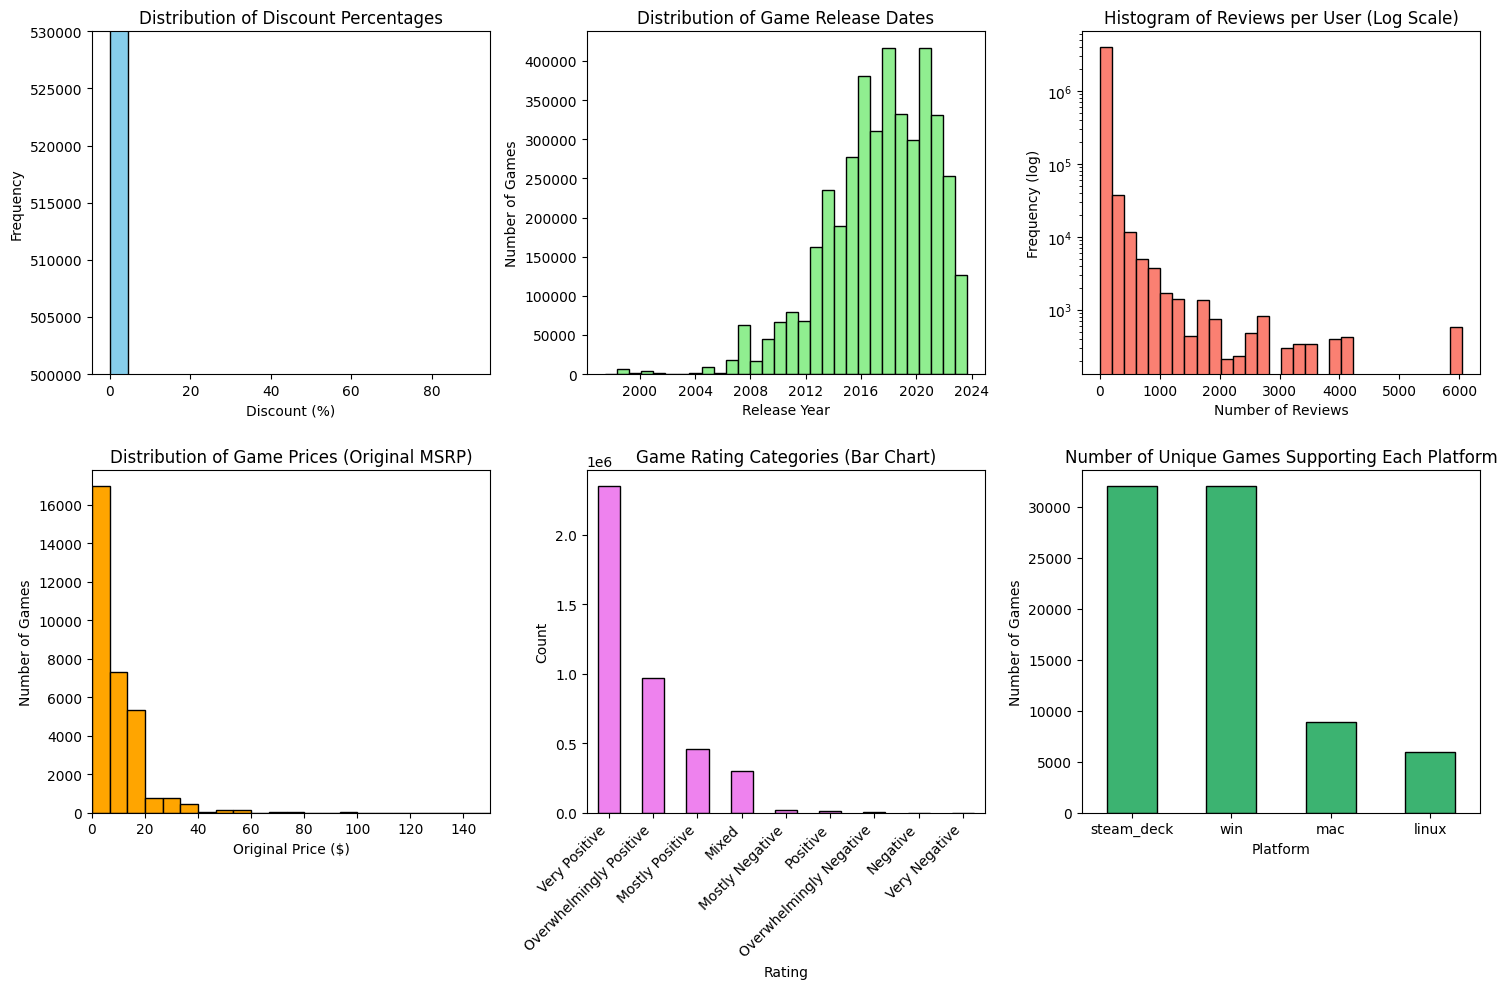

<Figure size 640x480 with 0 Axes>

In [20]:
# descriptive preliminary charts

# Make sure 'date_release' is in datetime format
vgrecs_cleaned_df["date_release"] = pd.to_datetime(vgrecs_cleaned_df["date_release"], errors='coerce')

plt.figure(figsize=(15, 10))

# 1. Histogram of discounts
plt.subplot(2, 3, 1)
plt.hist(vgrecs_cleaned_df["discount"].dropna(), bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Discount Percentages")
plt.xlabel("Discount (%)")
plt.ylabel("Frequency")
plt.ylim((500000, 530000))

# 2. Histogram of dates released
plt.subplot(2, 3, 2)
plt.hist(vgrecs_cleaned_df["date_release"].dropna(), bins=30, color="lightgreen", edgecolor="black")
plt.title("Distribution of Game Release Dates")
plt.xlabel("Release Year")
plt.ylabel("Number of Games")

# 3. Histogram of reviews per user (with log scale on y-axis)
plt.subplot(2, 3, 3)
plt.hist(vgrecs_cleaned_df["reviews"].dropna(), bins=30, color="salmon", edgecolor="black")
plt.yscale("log")  # <--- This line applies the log scale
plt.title("Histogram of Reviews per User (Log Scale)")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency (log)")

# # 4. Histogram of original price
unique_games = vgrecs_cleaned_df.groupby("app_id").first()
plt.subplot(2, 3, 4)
plt.hist(unique_games["price_original"].dropna(), bins=30, color="orange", edgecolor="black")
plt.title("Distribution of Game Prices (Original MSRP)")
plt.xlabel("Original Price ($)")
plt.xlim((0, 150))
plt.ylabel("Number of Games")


# 5. Histogram of product rating
plt.subplot(2, 3, 5)
vgrecs_cleaned_df["rating"].fillna("Unknown", inplace=True)
vgrecs_cleaned_df["rating"].value_counts().plot(kind="bar", color="violet", edgecolor="black")
plt.title("Game Rating Categories (Bar Chart)")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")


plt.subplot(2, 3, 6)
# Group by app_id to get unique games
unique_games = vgrecs_cleaned_df.groupby("app_id").first()
# Count number of unique games supporting each platform
platform_support = unique_games[["win", "mac", "linux", "steam_deck"]].sum().sort_values(ascending=False)
platform_support.plot(kind="bar", color="mediumseagreen", edgecolor="black")
plt.title("Number of Unique Games Supporting Each Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Games")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()


### Most games have modest or full discounts, with discount frequencies relatively evenly distributed, suggesting widespread promotional pricing. The majority of games were released between 2013 and 2021, indicating a recent surge in game publishing activity. User review counts are heavily skewed, with most users writing only a few reviews, while a tiny fraction contributes thousands, shown by the log scale. Original prices are clustered around $10–$20, and rating categories are overwhelmingly positive, with “Very Positive” and “Overwhelmingly Positive” dominating the sentiment distribution. Most games are supported on windows and steam deck, while mac and linux lag behind.

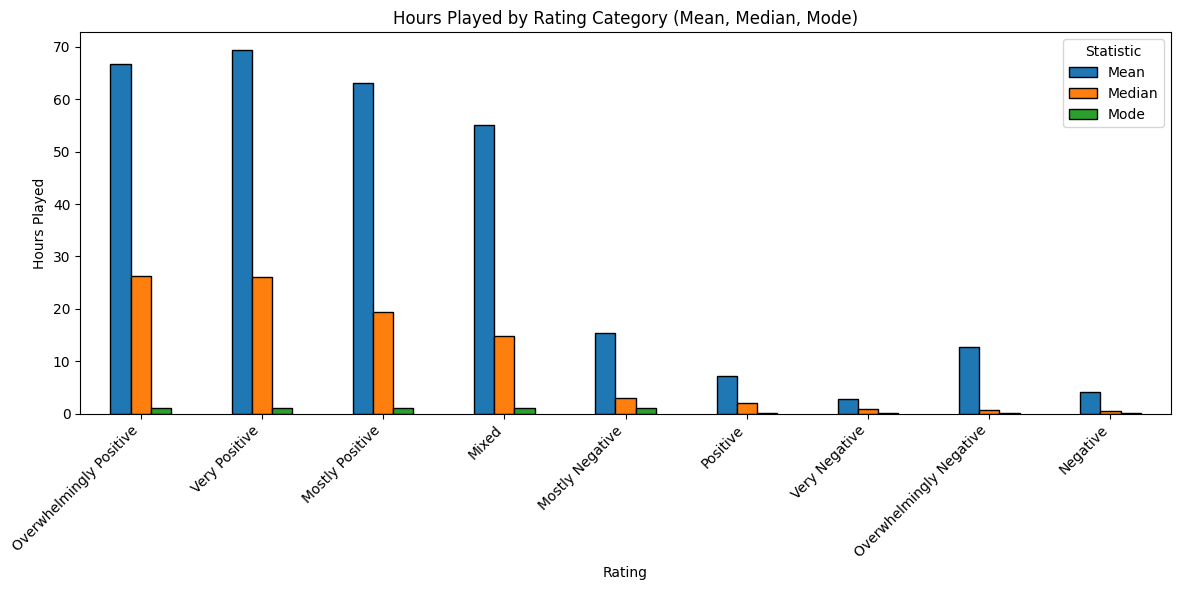

In [21]:
# Do hours played of the game generally affect the ratings people give them?
# clean and trim
subset = vgrecs_cleaned_df[["rating", "hours"]].dropna()
subset = subset[subset["hours"] < 500]  # remove extreme outliers
# get unique ratings sorted by median hours
ratings = subset.groupby("rating")["hours"].median().sort_values(ascending=False).index
# compute stats
mean_hours = subset.groupby("rating")["hours"].mean().reindex(ratings)
median_hours = subset.groupby("rating")["hours"].median().reindex(ratings)
mode_hours = subset.groupby("rating")["hours"].agg(lambda x: stats.mode(x, keepdims=True)[0][0]).reindex(ratings)
# recombine dat shi
hours_df = pd.DataFrame({
    "Mean": mean_hours,
    "Median": median_hours,
    "Mode": mode_hours
})
# plot
hours_df.plot(kind="bar", figsize=(12, 6), edgecolor="black")
plt.title("Hours Played by Rating Category (Mean, Median, Mode)")
plt.xlabel("Rating")
plt.ylabel("Hours Played")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Statistic")
plt.tight_layout()
plt.show()


### The chart shows that higher-rated games like “Overwhelmingly Positive” and “Very Positive” have significantly higher mean and median playtimes, suggesting users tend to play longer when they enjoy a game. As ratings decline, both mean and median hours drop — until a spike at “Overwhelmingly Negative”, where the mean unexpectedly rises again. This suggests a subset of users spend a long time with a game before leaving very negative feedback, possibly out of frustration or unmet expectations after heavy investment.

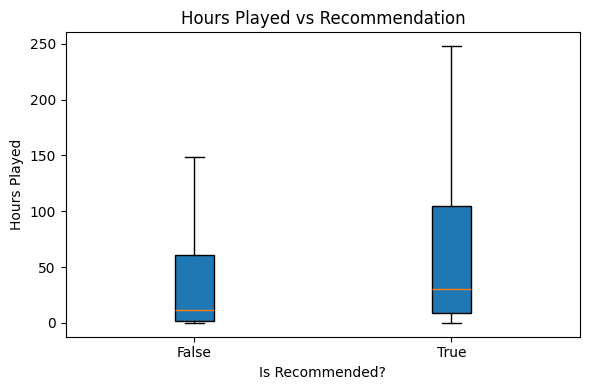

In [22]:
# How does hours played differ between users who recommend the game and those who don’t?

# Ensure the column is string type
vgrecs_cleaned_df["is_recommended"] = vgrecs_cleaned_df["is_recommended"].astype(str)

# Split the 'hours' by 'is_recommended' values
grouped_hours = [
    vgrecs_cleaned_df[vgrecs_cleaned_df["is_recommended"] == val]["hours"].dropna()
    for val in sorted(vgrecs_cleaned_df["is_recommended"].unique())
]

plt.figure(figsize=(6, 4))
plt.boxplot(grouped_hours, patch_artist=True, showfliers=False)

# Set labels
plt.xticks(ticks=[1, 2], labels=sorted(vgrecs_cleaned_df["is_recommended"].unique()), rotation=0)
plt.title("Hours Played vs Recommendation")
plt.xlabel("Is Recommended?")
plt.ylabel("Hours Played")
plt.tight_layout()
plt.show()



### Similarly, this chart shows that the users that recommend a game generally play it more often. This is useful because we know that while recommended/not recommended are close, more hours played (likely an indication of engagement) wil generally lead to more recommendations.

/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_5891/2977184682.py:6: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=subset, x="rating", y="hours", inner="quartile", scale="width", cut=0)


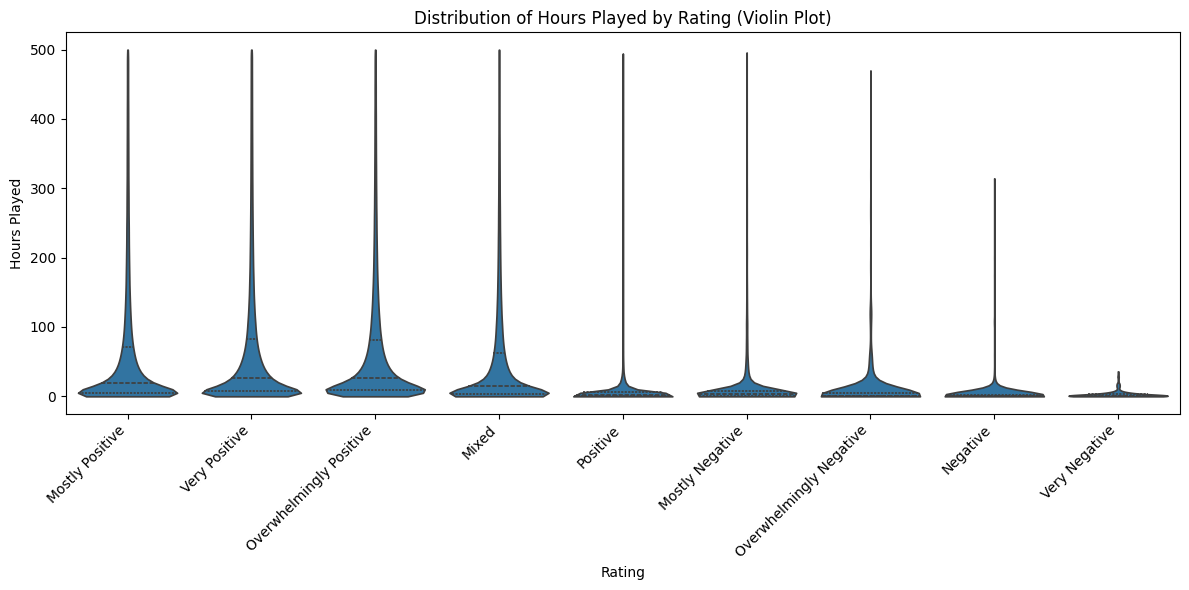

In [23]:

# Clean data
subset = vgrecs_cleaned_df[["rating", "hours"]].dropna()
subset = subset[subset["hours"] < 500]  # optional: trim extreme playtime outliers

plt.figure(figsize=(12, 6))
sns.violinplot(data=subset, x="rating", y="hours", inner="quartile", scale="width", cut=0)
plt.title("Distribution of Hours Played by Rating (Violin Plot)")
plt.xlabel("Rating")
plt.ylabel("Hours Played")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


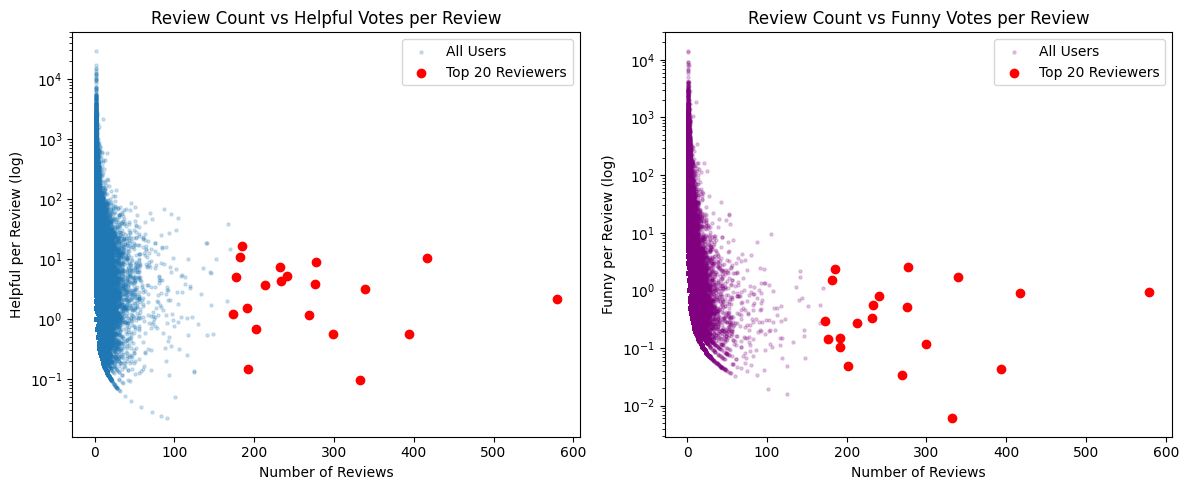

In [24]:
# review count versus average helpfulness

# Aggregate review stats
user_review_stats = vgrecs_cleaned_df.groupby("user_id").agg({
    "review_id": "count",
    "helpful": "sum",
    "funny": "sum"
}).rename(columns={"review_id": "review_count"})

# Drop users with zero reviews
user_review_stats = user_review_stats[user_review_stats["review_count"] > 0]

# Calculate per-review averages
user_review_stats["helpful_per_review"] = user_review_stats["helpful"] / user_review_stats["review_count"]
user_review_stats["funny_per_review"] = user_review_stats["funny"] / user_review_stats["review_count"]

# Identify top 20 users by review count
top_users = user_review_stats.sort_values("review_count", ascending=False).head(20)

# Plot
plt.figure(figsize=(12, 5))

# Helpful votes per review
plt.subplot(1, 2, 1)
plt.scatter(user_review_stats["review_count"], user_review_stats["helpful_per_review"], alpha=0.2, s=5, label="All Users")
plt.scatter(top_users["review_count"], top_users["helpful_per_review"], color="red", label="Top 20 Reviewers")
plt.yscale("log")
plt.title("Review Count vs Helpful Votes per Review")
plt.xlabel("Number of Reviews")
plt.ylabel("Helpful per Review (log)")
plt.legend()

# Funny votes per review
plt.subplot(1, 2, 2)
plt.scatter(user_review_stats["review_count"], user_review_stats["funny_per_review"], alpha=0.2, s=5, color="purple", label="All Users")
plt.scatter(top_users["review_count"], top_users["funny_per_review"], color="red", label="Top 20 Reviewers")
plt.yscale("log")
plt.title("Review Count vs Funny Votes per Review")
plt.xlabel("Number of Reviews")
plt.ylabel("Funny per Review (log)")
plt.legend()

plt.tight_layout()
plt.show()


### This chart shows that users with the most reviews (red dots) generally receive fewer helpful or funny votes per review compared to many users with fewer reviews. Most users cluster at low review counts and low engagement, but a few with fewer reviews achieve high vote efficiency, especially in the helpful category. This suggests that review quality or uniqueness—not quantity—is the key factor driving community engagement.

## Video Game Recommendations Dataset Conclusions

### Having created histograms and bar plots for several key features: discount percentages, game release dates, reviews per user, original game prices, and product rating categories. We also calculated and visualized the mean, median, and mode of hours played for each rating category to explore how gameplay time relates to review sentiment. The distributions in the dataset are highly skewed, especially for numeric features like hours played, reviews, and original price — most values are concentrated at the lower end, with a long tail of outliers. For example, the distribution of reviews per user follows a classic power-law, and original prices show a sharp peak around $10–$20. The product ratings are heavily skewed positive, with “Very Positive” and “Overwhelmingly Positive” dominating. Interestingly, while hours played generally increases with higher ratings, “Overwhelmingly Negative” also shows a high mean, indicating that long-playtime users can still leave very negative feedback. Changing bin sizes (especially for skewed features like hours and reviews) helped reveal the structure more clearly and emphasized the prevalence of extreme values. Finally, while users with the most reviews didn’t receive the most helpful or funny votes per review, some low-volume reviewers had much higher engagement, highlighting the importance of quality over quantity.

# Olist Dataset

## Features

| Column Name                   | Data Type | Description                                                                                      |
|------------------------------|-----------|--------------------------------------------------------------------------------------------------|
| order_id                     | object    | Unique ID of the order                                                                           |
| order_item_id                | int64     | Sequential number identifying number of items in the same order                                  |
| product_id                   | object    | Unique product identifier                                                                         |
| seller_id                    | object    | Seller unique identifier                                                                          |
| shipping_limit_date          | object    | Seller shipping limit date for handing the order to the logistic partner                         |
| price                        | float64   | Item price                                                                                        |
| freight_value                | float64   | Item freight value (split between items if multiple)                                             |
| product_category_name        | object    | Root category of product (in Portuguese)                                                         |
| product_name_lenght          | float64   | Number of characters in the product name                                                         |
| product_description_lenght  | float64   | Number of characters in the product description                                                  |
| product_photos_qty           | float64   | Number of published product photos                                                               |
| product_weight_g             | float64   | Product weight in grams                                                                          |
| product_length_cm            | float64   | Product length in centimeters                                                                    |
| product_height_cm            | float64   | Product height in centimeters                                                                    |
| product_width_cm             | float64   | Product width in centimeters                                                                     |
| product_category_name_english| object    | Product category name in English                                                                 |
| customer_id                  | object    | Key to the orders dataset; each order has a unique customer_id                                   |
| order_purchase_timestamp     | object    | Purchase timestamp                                                                                |
| review_creation_date         | object    | Date the satisfaction survey was sent to the customer                                            |
| review_answer_timestamp      | object    | Timestamp of the customer's survey response                                                      |
| customer_unique_id           | object    | Unique identifier of a customer                                                                  |
| customer_state               | object    | Customer's state/province in Brazil (2-letter abbreviation)                                      |
| review_score                 | float64   | Score from 1 to 5 given by the customer on the satisfaction survey                               |


In [25]:
# consolidate variables
olist_cleaned_df = olist_cleaned_df.copy()
olist_encoded_df = olist_cleaned_encoded_df.copy()

/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_5891/1003928910.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[6].set_xticklabels(category_counts.index, ha='right')


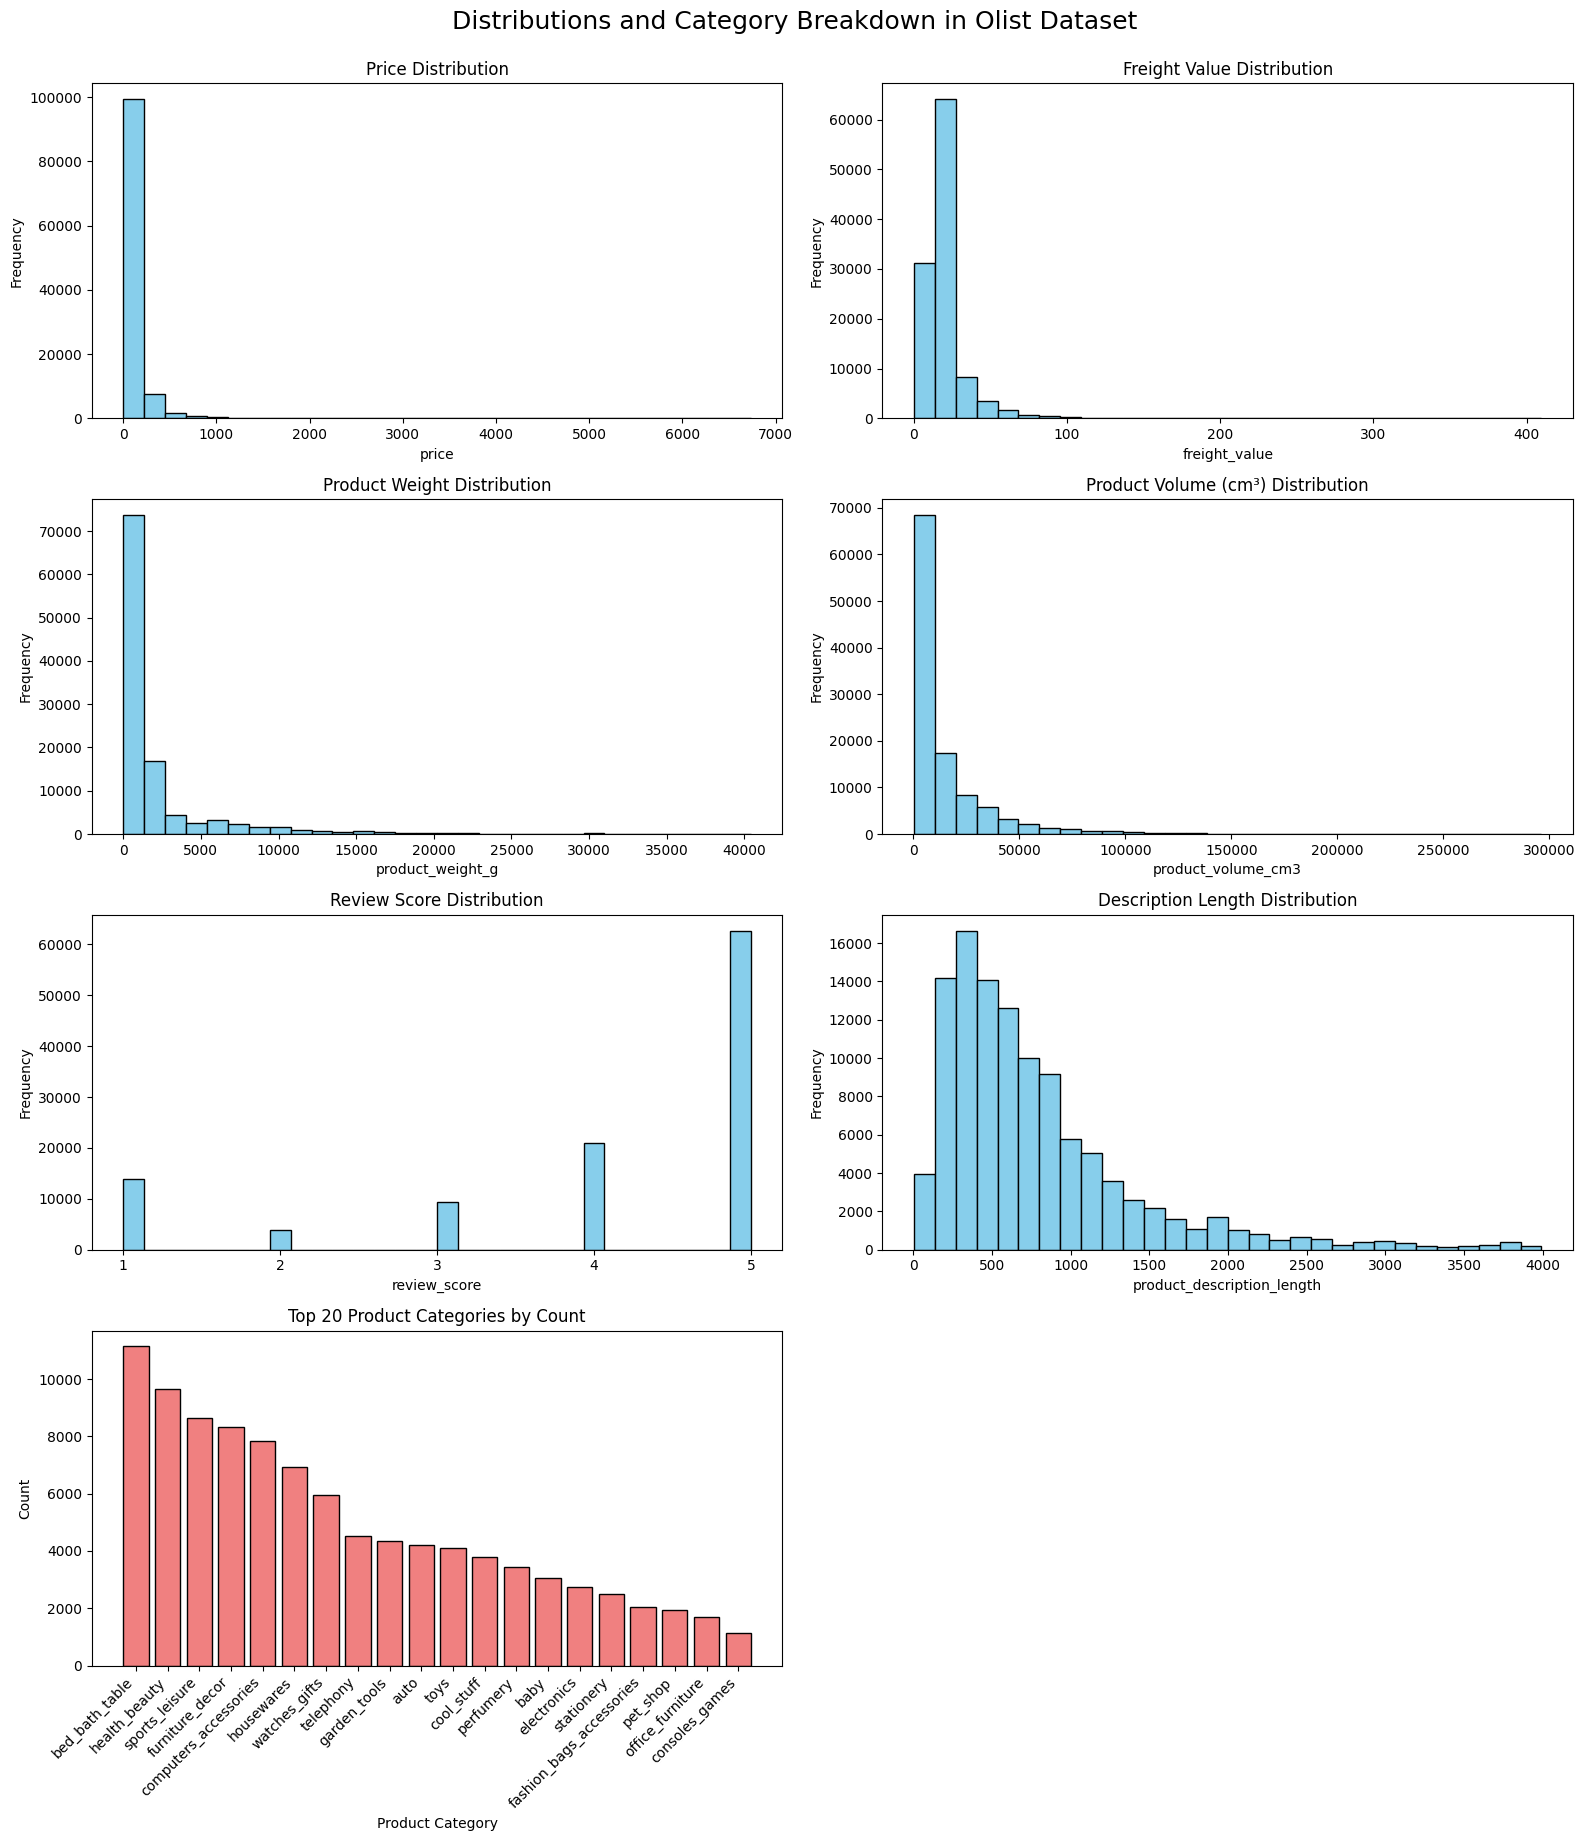

In [26]:
# analyse the price, freight value, product weight, volume, review score, and descriptions


olist_cleaned_df["product_volume_cm3"] = (
    olist_cleaned_df["product_length_cm"] *
    olist_cleaned_df["product_height_cm"] *
    olist_cleaned_df["product_width_cm"]
)

# Correct column name
features_updated = [
    ("price", "Price Distribution"),
    ("freight_value", "Freight Value Distribution"),
    ("product_weight_g", "Product Weight Distribution"),
    ("product_volume_cm3", "Product Volume (cm³) Distribution"),
    ("review_score", "Review Score Distribution"),
    ("product_description_length", "Description Length Distribution"),
]

# Create the figure with 4 rows and 2 columns of subplots
fig, axs = plt.subplots(4, 2, figsize=(16, 18))
axs = axs.flatten()

# Plot histograms
for i, (col, title) in enumerate(features_updated):
    axs[i].hist(olist_cleaned_df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    axs[i].set_title(title)
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Frequency")
    if col == "review_score":
        axs[i].set_xticks(range(1, 6))  # Force integer ticks from 0 to 5

# Plot bar chart for product category in the 7th subplot
category_counts = olist_cleaned_df["product_category_name_english"].value_counts().head(20)
axs[6].bar(category_counts.index, category_counts.values, color='lightcoral', edgecolor='black')
axs[6].set_title("Top 20 Product Categories by Count")
axs[6].set_xlabel("Product Category")
axs[6].set_ylabel("Count")
axs[6].tick_params(axis='x', labelrotation=45)
axs[6].set_xticklabels(category_counts.index, ha='right')

# Remove the 8th (unused) subplot
fig.delaxes(axs[7])

# Layout and title
plt.tight_layout()
plt.suptitle("Distributions and Category Breakdown in Olist Dataset", fontsize=18, y=1.02)
plt.show()


/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_5891/4118761510.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


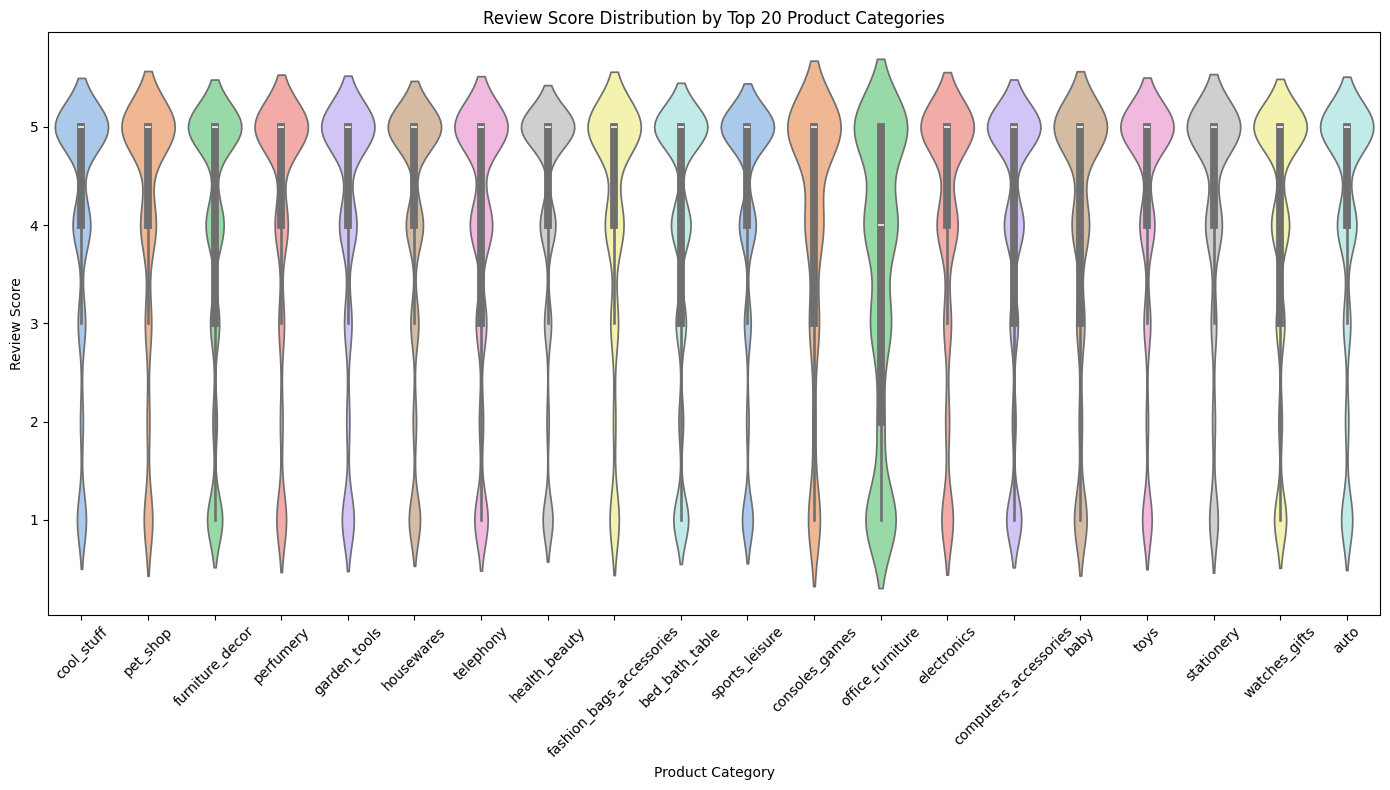

In [27]:
# top 20 products vs thei review score distribution

# Get the top 20 product categories by count
top_20_categories = (
    olist_cleaned_df["product_category_name_english"]
    .value_counts()
    .head(20)
    .index
)

# Filter dataset for only those top 20 categories
top_category_reviews = olist_cleaned_df[
    olist_cleaned_df["product_category_name_english"].isin(top_20_categories)
]

# Create a violin plot of review score distribution across these categories
fig, ax = plt.subplots(figsize=(14, 8))
sns.violinplot(
    data=top_category_reviews,
    x="product_category_name_english",
    y="review_score",
    palette="pastel",
    inner="box",
    ax=ax
)

ax.set_title("Review Score Distribution by Top 20 Product Categories")
ax.set_xlabel("Product Category")
ax.set_ylabel("Review Score")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### This violin plot shows that most product categories in Olist receive predominantly 5-star reviews, but some show wider distributions with tails toward lower scores. Categories like office_furniture and consoles_games show a bimodal pattern, indicating inconsistent customer satisfaction within those segments. In contrast, categories such as watches_gifts, pet_shop, and health_beauty have tighter, high-score distributions, suggesting more reliable experiences. Overall, while positive reviews dominate, certain categories appear more prone to dissatisfaction, possibly due to variability in product quality or delivery performance.

/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_5891/425548409.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_grouped = filtered_df.groupby(price_bins)["review_score"].mean().reset_index()


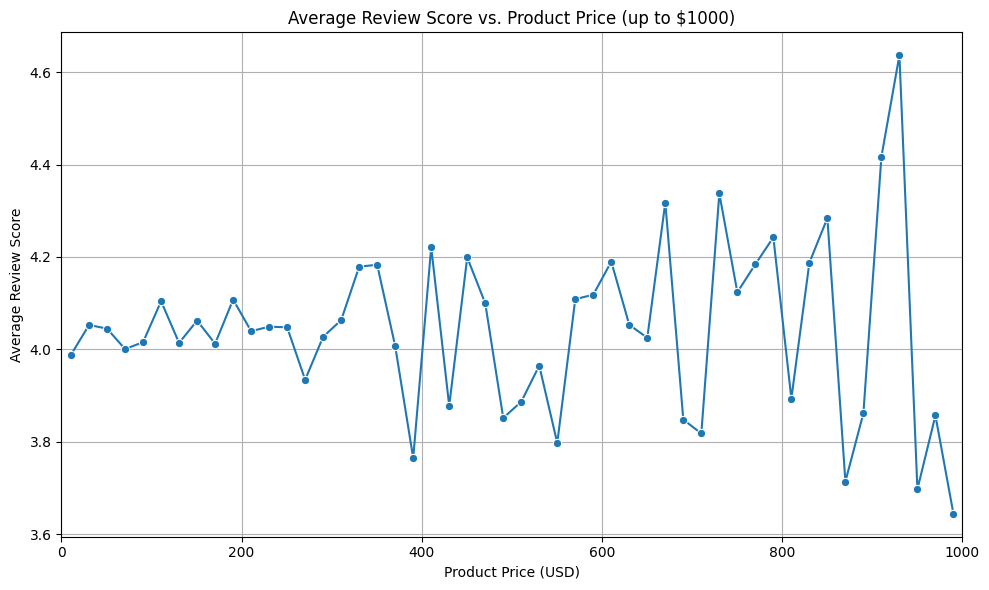

In [28]:
# Do customers rate expensive products more harshly? Any pricing sweet spot for good reviews?

# # Remove extreme outliers in price to avoid skewing the trend
filtered_df = olist_cleaned_df[olist_cleaned_df["price"] <= 1000]

# Bin prices for smoothing the average trend
price_bins = pd.cut(filtered_df["price"], bins=50)
price_grouped = filtered_df.groupby(price_bins)["review_score"].mean().reset_index()
price_grouped["price_midpoint"] = price_grouped["price"].apply(lambda x: x.mid)

# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(data=price_grouped, x="price_midpoint", y="review_score", marker="o")
plt.title("Average Review Score vs. Product Price (up to $1000)")
plt.xlabel("Product Price (USD)")
plt.ylabel("Average Review Score")
plt.xlim((0, 1000))
plt.grid(True)
plt.tight_layout()
plt.show()


### Customers generally rate products consistently well across the entire price range up to $1,000, with no strong evidence of harsher reviews for more expensive items. There's a stable “sweet spot” of high average ratings between $100 and $400. The increased volatility at higher prices suggests fewer reviews, so interpretations in that range should be made cautiously

/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_5891/3450354575.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


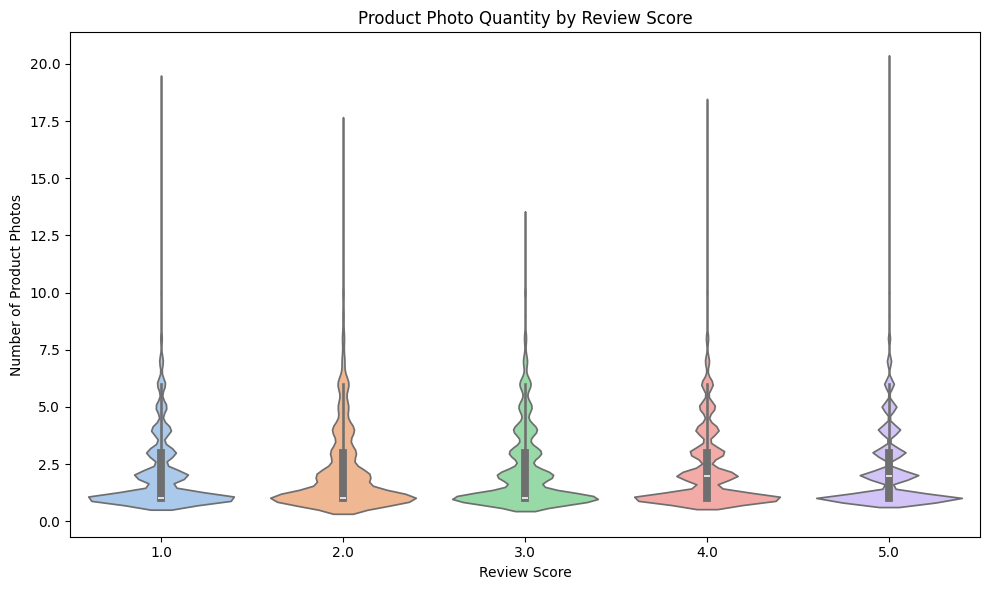

In [29]:
# checking product photo quantity vs review score
# Filter rows with non-null review_score and product_photos_qty
photo_review_df = olist_cleaned_df[
    olist_cleaned_df["review_score"].notna() &
    olist_cleaned_df["product_photos_qty"].notna()
]

# Create a violin plot: number of photos vs. review score
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=photo_review_df,
    x="review_score",
    y="product_photos_qty",
    palette="pastel",
    inner="box",
    ax=ax
)

ax.set_title("Product Photo Quantity by Review Score")
ax.set_xlabel("Review Score")
ax.set_ylabel("Number of Product Photos")
plt.tight_layout()
plt.show()


### The violin plot shows that most products have only 1 or 2 photos, regardless of the review score given by customers. There is a long tail of listings with more images, but these are rare and evenly distributed across all review scores. This suggests that the number of product photos does not significantly influence customer satisfaction in this dataset. Overall, buyers seem to form opinions based on other factors like delivery experience or product quality, rather than the number of description photos.

# Olist Dataset Conclusions

### The distributions show that key numerical features like price, freight value, product weight, and volume are heavily right-skewed, with most values clustered at the low end and a few extreme outliers that likely reflect data entry errors or inconsistencies (e.g., unrealistic product volumes). Review scores are strongly skewed toward 5 stars, indicating generally positive customer feedback or a bias in who chooses to leave reviews, but a lot of people will negative reviews as well if they are likely dissatisfied with the product or delivery. Product descriptions vary widely in length, but most are reasonably concise, with a few excessively long entries likely due to unstandardized inputs. Some of the product categories dominate the product lists. Shipping time and photo quantity don’t seem to affect review scores much. However, review score distributions do vary by category—some get consistently high ratings while others show more mixed or low scores. Overall, the data is usable but needs cleaning before doing deeper analysis.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

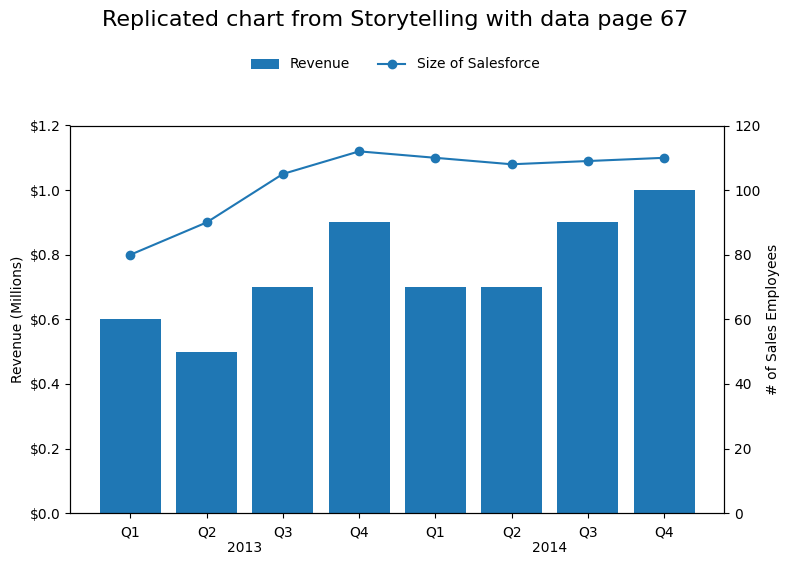

In [30]:
# fake data
df = pd.DataFrame({
    "Year":      ["2013"] * 4 + ["2014"] * 4,
    "Quarter":   ["Q1", "Q2", "Q3", "Q4"] * 2,
    "Revenue_M": [0.6, 0.5, 0.7, 0.9, 0.7, 0.7, 0.9, 1.0],
    "Salesforce_Size": [80, 90, 105, 112, 110, 108, 109, 110]
})

x = range(len(df))

# grab the figure and axes to manipulate them
fig, ax1 = plt.subplots(figsize=(8, 5))

# set the first lable
ax1.bar(x, df["Revenue_M"], width=0.8, label="Revenue")
ax1.set_ylabel("Revenue (Millions)")
ax1.set_ylim(0, 1.2)
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:.1f}'))

# copy the first y axis for the number of employees
ax2 = ax1.twinx()
ax2.plot(x, df["Salesforce_Size"], marker="o", label="Size of Salesforce")
ax2.set_ylabel("# of Sales Employees")
ax2.set_ylim(0, 120)

# set first x axis ticks to be the quarterr
ax1.set_xticks(x)
ax1.set_xticklabels(df["Quarter"])

# set next x axis ticks to be the year, just like the graph
year_positions = [1.5, 5.5] # kinda the midpoint of the two 4‑quarter groups, trial and error
year_labels    = ["2013", "2014"]
ax1.set_xticks(year_positions, minor=True)
ax1.set_xticklabels(year_labels, minor=True)

ax1.tick_params(axis="x", which="major", pad=5)   # quarters
ax1.tick_params(axis="x", which="minor", pad=20)  # years pushed further down
ax1.tick_params(axis="x", which="minor", length=0)  # hide minor ticks

# legend
handles, labels = [], []
for ax in (ax1, ax2):
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# add a figure‑level legend centred horizontally, laid out in one row
fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 1.05),
           ncol=2,
           frameon=False)

fig.suptitle("Replicated chart from Storytelling with data page 67", y=1.12, fontsize=16)
fig.tight_layout()
plt.show()
